In [ ]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from astropy.timeseries import LombScargle
import astropy.units as u

from nestar.ARIMA import ARIMA_fast
import nestar.ARIMA_ns as ARIMA_ns
from nestar.priors import normal_prior
from nestar.model_comparison_utils import ARIMA_model_comparison
from nestar import arima_results as ar

/Users/ajinkya/myenv/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


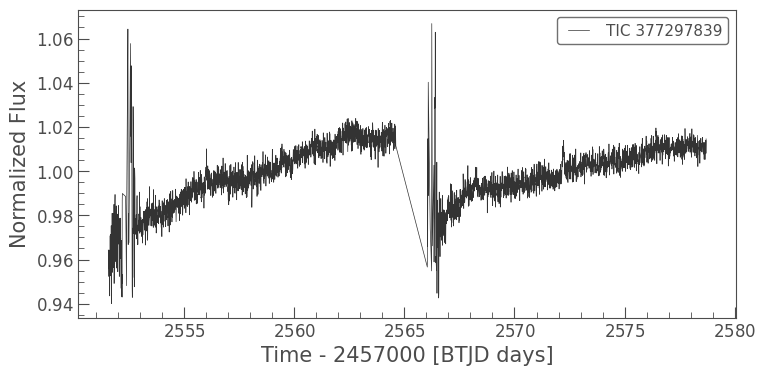

In [19]:
all_lcs = lk.search_lightcurve('3C 273')
lcf = all_lcs[8].download()
lc = lcf.remove_outliers(sigma=5).normalize().remove_nans()
lc.plot()
plt.show()

In [20]:
flux = np.array(lc['flux'].value)
flux_err = np.array(lc['flux_err'].value)
time = np.sort(np.array(lc['time'].value))
np.where(np.diff(time)>0.1)

(array([  86, 1732]),)

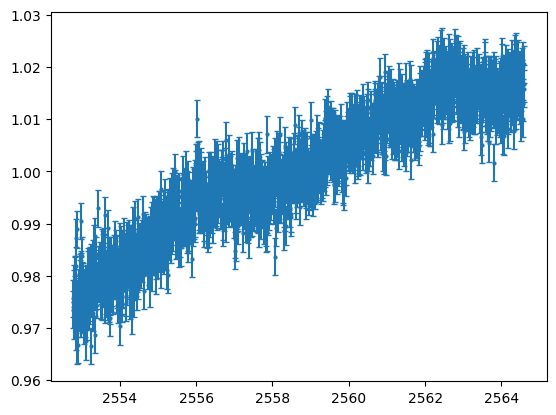

In [21]:
quasar_time = time[120:1730]
quasar_flux = flux[120:1730]
quasar_error = flux_err[120:1730]
plt.errorbar(quasar_time,quasar_flux,yerr=quasar_error,ms=2,fmt='o',capsize=2)
plt.show()

In [29]:
from model_comparison_utils import stationarity_test
stationarity_test(quasar_flux)
stationarity_test(np.diff(quasar_flux,1))

Results of Dickey-Fuller Test:
Test Statistic                   -1.623081
p-value                           0.471114
#Lags Used                       23.000000
Number of Observations Used    1586.000000
Critical Value (1%)              -3.434480
Critical Value (5%)              -2.863364
Critical Value (10%)             -2.567741
dtype: float64
Non stationarity acc to ADF test
Results of KPSS Test:
Test Statistic            5.853438
p-value                   0.010000
Lags Used                26.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
Series non-stationary acc to KPSS Test
Results of Dickey-Fuller Test:
Test Statistic                -1.352102e+01
p-value                        2.734927e-25
#Lags Used                     2.200000e+01
Number of Observations Used    1.586000e+03
Critical Value (1%)           -3.434480e+00
Critical Value (5%)           -2.863364e+00
Crit

/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/model_comparison_utils.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")
/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/model_comparison_utils.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if kpss_output[1] < 0.05:
/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/model_comparison_utils.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")
/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/model_co

(None, None)

In [30]:
quasar_model_compare = ARIMA_model_comparison(data=quasar_flux,max_p=7,max_q=7,d=1,
                                              meas_sigma=None,num_live=200,num_delete=50,
                                              seed=30,mu_mean=1,mu_scale=5,file_name="Heatmap Data/3C_273_evidences.txt")
quasar_model_compare.run()

/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_17202/2602950713.py:1: UserWarning: 'Heatmap Data/3C_273_evidences.txt' already exists and will be overwritten by this run. If you meant to keep it, rename/move it (or change file_name) before calling .run().
  quasar_model_compare = ARIMA_model_comparison(data=quasar_flux,max_p=7,max_q=7,d=1,
/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_17202/2602950713.py:4: UserWarning: 'Heatmap Data/3C_273_evidences.txt' already exists and will be overwritten by this run. 
  quasar_model_compare.run()


Running Nested Sampling for fitting ARIMA (0, 1, 1) model...


Dead points: 6900 dead points [00:16, 410.61 dead points/s]


Finished Nested Sampling with a total runtime of : 17.26 seconds
----------------------x-------------------x---------------------x------
Evidence for (0, 1, 1) : 6315.567051467644 ; Error : 0.40882254530392964
V : 0.680155 ; D0 Occam : 0.000 ; Net prior-volume effect : 0.385
Highest Evidence so far : 6315.567051467644 for order : (0, 1, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (0, 1, 2) model...


Dead points: 7300 dead points [00:26, 272.85 dead points/s]


...

Finished Nested Sampling with a total runtime of : 3093.45 seconds
----------------------x-------------------x---------------------x------
Evidence for (7, 1, 6) : 6528.897518313532 ; Error : 0.8805025930445565
V : 6.088235294117647e-05 ; D0 Occam : -15.072 ; Net prior-volume effect : -5.365
Highest Evidence so far : 6654.691473019436 for order : (1, 1, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (7, 1, 7) model...
Acceptance rate: 0.0000, Total drawn: 400000
Acceptance rate: 0.0000, Total drawn: 600000
Acceptance rate: 0.0000, Total drawn: 800000
Acceptance rate: 0.0000, Total drawn: 1000000
Acceptance rate: 0.0000, Total drawn: 1200000
Acceptance rate: 0.0000, Total drawn: 1400000
Acceptance rate: 0.0000, Total drawn: 1600000
Acceptance rate: 0.0000, Total drawn: 1800000
Acceptance rate: 0.0000, Total drawn: 2000000
Acceptance rate: 0.0000, Total drawn: 2200000
Acceptance rate: 0.0000, Total drawn: 2400000
Accep

Dead points: 15000 dead points [34:35,  7.23 dead points/s]


Finished Nested Sampling with a total runtime of : 2077.30 seconds


/Users/ajinkya/myenv/lib/python3.13/site-packages/anesthetic/samples.py:1336: RuntimeWarning: 850 out of 15200 samples have logL <= logL_birth,
832 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(


----------------------x-------------------x---------------------x------
Evidence for (7, 1, 7) : 6493.173304761047 ; Error : 0.6361158735050195
V : 1.8454545454545456e-05 ; D0 Occam : -21.383 ; Net prior-volume effect : -10.482
Highest Evidence so far : 6654.691473019436 for order : (1, 1, 1)
----------------------x-------------------x----------------------x-----


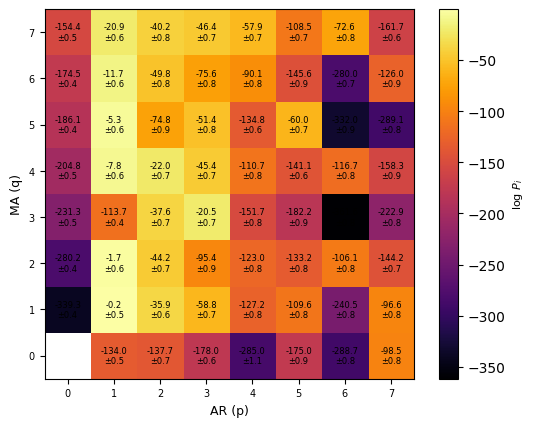

In [33]:
quasar_evidence = ar.EvidenceResults("Heatmap Data/3C_273_evidences.txt",max_p=7)
quasar_evidence.plot_evidence_heatmap()

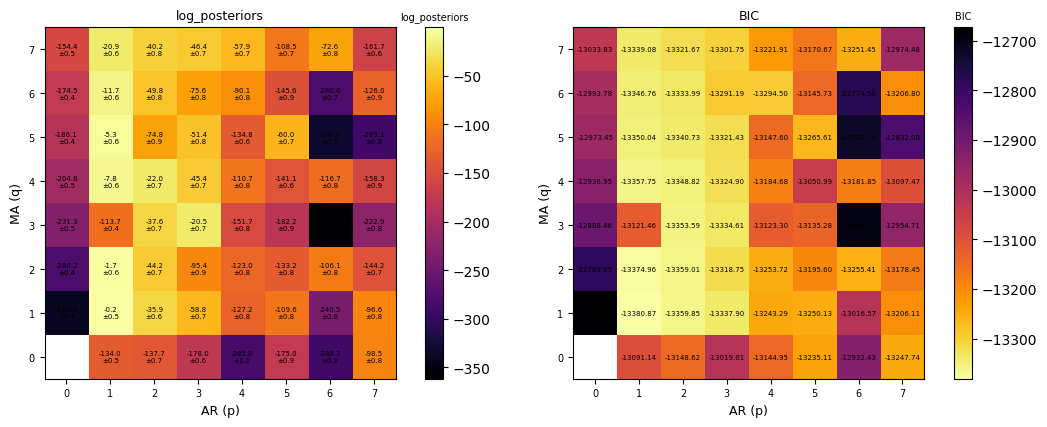

In [34]:
quasar_evidence.compare(quantity2="BIC")

In [36]:
logP_quasar = quasar_evidence.log_posteriors
quasar_errs = quasar_evidence.evidence_err
print(f"Best-fit model ARIMA(1,1,1) with logP: {max(logP_quasar)} and error:{quasar_errs[np.argmax(logP_quasar)]}")

Best-fit model ARIMA(1,1,1) with logP: -0.2179883652306671 and error:0.5110724280505877


In [37]:
quasar_evidence.cumulative_posterior_mass(5)

{'n': 5,
 'top_orders': [(1, 1, 1), (1, 1, 2), (1, 1, 5), (1, 1, 4), (1, 1, 6)],
 'individual_mass': array([8.04134798e-01, 1.90357563e-01, 5.08753063e-03, 4.11810369e-04,
        8.29639834e-06]),
 'cumulative_mass': 0.9999999976144489}

In [47]:
quasar_model = ARIMA_ns.ARIMA_Nested_Sampler(data=quasar_flux,meas_sigma=None,order=(1,1,1),mu_mean=0,mu_scale=5,num_live=1000,num_delete=50,seed=35,prior_type="normal")
quasar_model.summary()

Running Nested Sampling for fitting ARIMA (1, 1, 1) model...


Dead points: 59150 dead points [05:28, 180.24 dead points/s]


Finished Nested Sampling with a total runtime of : 328.60 seconds
||NESTED SAMPLING SUMMARY RESULTS||
----------------------------------------------------
Nested sampling runtime: 328.60 seconds
----------------------------------------------------
Posterior mean for phi_1 : 0.9934991761514673
Posterior mean for theta_1 : -0.9170300879200561
Posterior mean for sigma : 0.0037595929588673843
Posterior mean for mu : 1.812181360620695e-05
Posterior mean for init_y_1 : 7.811472311165145e-05
---------------------------------------------------
Log Evidence: 6655.12 ± 0.25
-------x----------------x-------------x------------


PosteriorResults: order=(1, 1, 1), prior_type='normal' (inferred from chain)


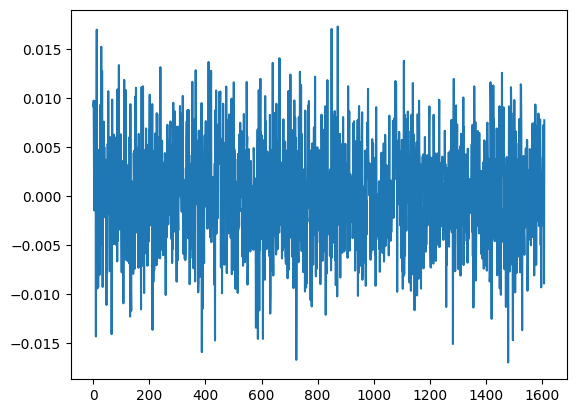

In [50]:
#quasar_model.posterior_samples.to_csv('NS Chains/3C_273_samples.csv')
quasar_posterior = ar.PosteriorResults('NS Chains/old/3C_273_samples.csv',quasar_flux,d=1)
quasar_point_estiamte = quasar_posterior.point_estimate_forecast()
quasar_residual = quasar_point_estiamte['residuals']
plt.plot(quasar_residual)
plt.show()

In [52]:
import statsmodels.api as sm
sm.stats.acorr_ljungbox(quasar_residual, lags=np.arange(5,16,1),return_df=True,model_df=2)

,lb_stat,lb_pvalue
5,1.585684,0.662640
6,1.658416,0.798257
7,1.662976,0.893531
8,1.664013,0.947866
9,6.327946,0.502021
10,7.437283,0.490269
11,7.459216,0.589422
12,8.176249,0.611626
13,8.616109,0.657280
14,10.058913,0.610792


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/arima_results.py:1006: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


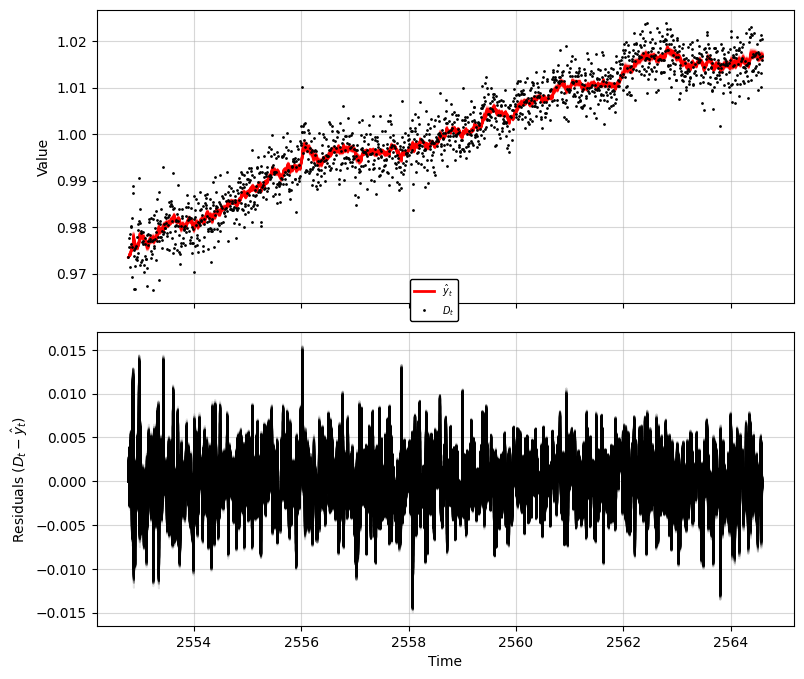

In [56]:
quasar_posterior.insample_forecast(quasar_time)
plt.show()

In [22]:
##Tau sensitivity checks around best-fit neighbour and extreme models:
orders = [(1,1,0),(1,1,1),(1,1,2),(2,1,0),(2,1,1),(2,1,2),(0,1,1),(0,1,2)]

tau_evidences = []
tau_err = []
for tau in [1.7,15]:
 neighbour_evidences = []
 neighbour_evidences_err = []
 for order in orders:
    test_model = ARIMA_ns.ARIMA_Nested_Sampler(data=quasar_flux,order=order,num_live=200,num_delete=50,mu_mean=0,mu_scale=tau,seed=30)
    evidence = test_model.log_evidence
    neighbour_evidences.append(evidence)
    neighbour_evidences_err.append(test_model.log_evidence_err)
 tau_evidences.append(neighbour_evidences)
 tau_err.append(neighbour_evidences_err)

Running Nested Sampling for fitting ARIMA (1, 1, 0) model...


Dead points: 9650 dead points [00:38, 250.72 dead points/s]


Finished Nested Sampling with a total runtime of : 38.87 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 1) model...


Dead points: 9850 dead points [00:54, 182.29 dead points/s]


Finished Nested Sampling with a total runtime of : 54.47 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 2) model...


...

Finished Nested Sampling with a total runtime of : 339.04 seconds
Running Nested Sampling for fitting ARIMA (0, 1, 1) model...


Dead points: 7050 dead points [00:16, 418.02 dead points/s]


Finished Nested Sampling with a total runtime of : 17.26 seconds
Running Nested Sampling for fitting ARIMA (0, 1, 2) model...


Dead points: 7550 dead points [00:27, 274.06 dead points/s]


Finished Nested Sampling with a total runtime of : 27.97 seconds


In [23]:
print(tau_evidences[0])
print(tau_err[0])
print(tau_evidences[1])
print(tau_err[1])

[np.float64(6512.1643287335655), np.float64(6659.508853319699), np.float64(6658.2536579504385), np.float64(6535.1891967285455), np.float64(6640.092746410351), np.float64(6613.450245020305), np.float64(6316.4352943293325), np.float64(6375.144465200972)]
[np.float64(0.5393197380525314), np.float64(0.5082767861439398), np.float64(0.5013877350737643), np.float64(0.5400679045197269), np.float64(0.5171996363082854), np.float64(0.8498664693434539), np.float64(0.4178697394131505), np.float64(0.4617186595436352)]
[np.float64(6510.586157571286), np.float64(6652.465837513554), np.float64(6648.077241783558), np.float64(6503.078713715133), np.float64(6562.203061552148), np.float64(6617.69897543834), np.float64(6314.559702320486), np.float64(6373.312986021518)]
[np.float64(0.4972225145995931), np.float64(0.5820592874296924), np.float64(0.5771509336438763), np.float64(0.7348083404799258), np.float64(0.6367805153258096), np.float64(0.714116458557828), np.float64(0.43412517163989156), np.float64(0.3897

In [ ]:
print(np.argmax(tau_evidences[0]))
print(np.argmax(tau_evidences[1])) #stable against tau

1
1


In [46]:
quasar_model_compare_pacf = ARIMA_model_comparison(data=quasar_flux,max_p=7,max_q=7,d=1,
                                              meas_sigma=None,num_live=200,num_delete=50,
                                              seed=30,mu_mean=1,mu_scale=5,prior_type="pacf",file_name="Heatmap Data/3C_273_evidences_pacf.txt")
quasar_model_compare_pacf.run()

/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_17202/4269094532.py:1: UserWarning: 'Heatmap Data/3C_273_evidences_pacf.txt' already exists and will be overwritten by this run. If you meant to keep it, rename/move it (or change file_name) before calling .run().
  quasar_model_compare_pacf = ARIMA_model_comparison(data=quasar_flux,max_p=7,max_q=7,d=1,
/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_17202/4269094532.py:4: UserWarning: 'Heatmap Data/3C_273_evidences_pacf.txt' already exists and will be overwritten by this run. 
  quasar_model_compare_pacf.run()


Running Nested Sampling for fitting ARIMA (0, 1, 1) model...


Dead points: 6950 dead points [00:17, 391.57 dead points/s]


Finished Nested Sampling with a total runtime of : 18.19 seconds
----------------------x-------------------x---------------------x------
Evidence for (0, 1, 1) : 6315.349631514721 ; Error : 0.3657909710989095
V : 1.0 ; D0 Occam : 0.000 ; Net prior-volume effect : 0.000
Highest Evidence so far : 6315.349631514721 for order : (0, 1, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (0, 1, 2) model...


Dead points: 7750 dead points [00:28, 268.45 dead points/s]


...

Finished Nested Sampling with a total runtime of : 1429.70 seconds
----------------------x-------------------x---------------------x------
Evidence for (7, 1, 5) : 6585.201747346168 ; Error : 0.6484695825892233
V : 1.0 ; D0 Occam : -34.335 ; Net prior-volume effect : -34.335
Highest Evidence so far : 6658.113225649051 for order : (1, 1, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (7, 1, 6) model...


Dead points: 25450 dead points [29:25, 14.41 dead points/s]


Finished Nested Sampling with a total runtime of : 1767.21 seconds
----------------------x-------------------x---------------------x------
Evidence for (7, 1, 6) : 6561.019073305055 ; Error : 0.8141966309273476
V : 1.0 ; D0 Occam : -17.260 ; Net prior-volume effect : -17.260
Highest Evidence so far : 6658.113225649051 for order : (1, 1, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (7, 1, 7) model...


Dead points: 29150 dead points [14:28:13,  1.79s/ dead points]


Finished Nested Sampling with a total runtime of : 52094.61 seconds
----------------------x-------------------x---------------------x------
Evidence for (7, 1, 7) : 6543.647843407792 ; Error : 0.9013310826920637
V : 1.0 ; D0 Occam : -29.426 ; Net prior-volume effect : -29.426
Highest Evidence so far : 6658.113225649051 for order : (1, 1, 1)
----------------------x-------------------x----------------------x-----


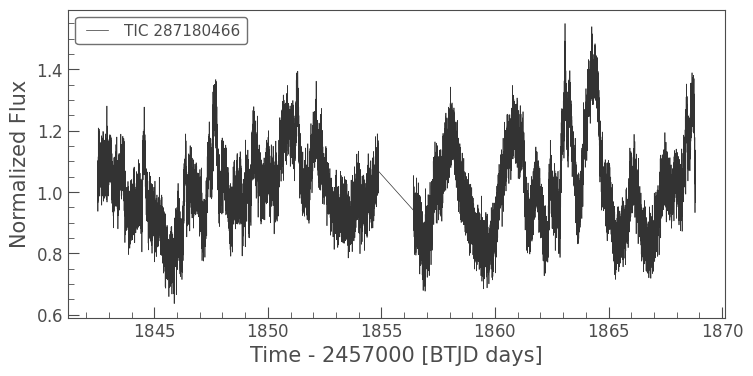

In [2]:
all_lcs = lk.search_lightcurve('S4 0954+65')
lc = all_lcs[0].download().remove_outliers(sigma=5).normalize()
lc.plot()
plt.show()

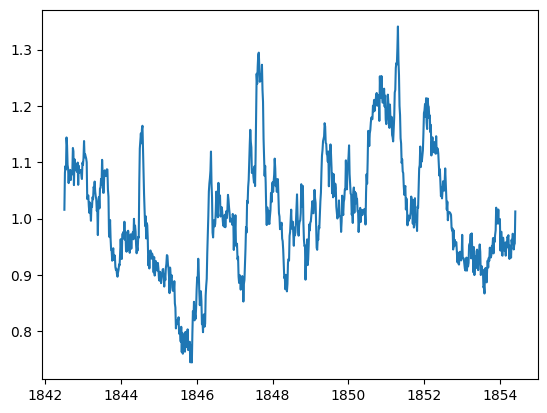

In [3]:
lc_binned = lc.bin(time_bin_size=0.014*u.day)
blazar_flux = np.array(lc_binned['flux'].value)[:850]
blazar_error = np.array(lc_binned['flux_err'].value)[:850]
blazar_time = np.array(lc_binned['time'].value)[:850]
plt.plot(blazar_time,blazar_flux)
plt.show()

In [17]:
grid_search_1 = ARIMA_model_comparison(data=blazar_flux,max_p=7,max_q=7,d=1,num_live=200,num_delete=50,seed=50,mu_mean=1,mu_scale=5,meas_sigma=None,file_name='Heatmap Data/S4_0954+65_evidences_new.txt')
grid_search_1.run()

/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_45548/3192831447.py:2: UserWarning: 'Heatmap Data/S4_0954+65_evidences_new.txt' already exists and will be overwritten by this run. 
  grid_search_1.run()


Running Nested Sampling for fitting ARIMA (0, 1, 1) model...


Dead points: 5800 dead points [00:11, 505.66 dead points/s]


Finished Nested Sampling with a total runtime of : 11.98 seconds
----------------------x-------------------x---------------------x------
Evidence for (0, 1, 1) : 1107.4328231898637 ; Error : 0.35717664757642575
V : 0.68087 ; D0 Occam : 0.000 ; Net prior-volume effect : 0.384
Highest Evidence so far : 1107.4328231898637 for order : (0, 1, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (0, 1, 2) model...


Dead points: 6250 dead points [00:18, 330.68 dead points/s]


...

Finished Nested Sampling with a total runtime of : 622.99 seconds
----------------------x-------------------x---------------------x------
Evidence for (7, 1, 5) : 1920.5942380618462 ; Error : 0.5338233660286674
V : 0.00016214285714285715 ; D0 Occam : -13.470 ; Net prior-volume effect : -4.743
Highest Evidence so far : 1933.2984291160246 for order : (1, 1, 2)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (7, 1, 6) model...
Acceptance rate: 0.0001, Total drawn: 400000
Acceptance rate: 0.0001, Total drawn: 600000
Acceptance rate: 0.0001, Total drawn: 800000
Acceptance rate: 0.0001, Total drawn: 1000000
Acceptance rate: 0.0001, Total drawn: 1200000
Acceptance rate: 0.0001, Total drawn: 1400000
Acceptance rate: 0.0001, Total drawn: 1600000
Acceptance rate: 0.0001, Total drawn: 1800000
Acceptance rate: 0.0001, Total drawn: 2000000
Acceptance rate: 0.0001, Total drawn: 2200000
Acceptance rate: 0.0001, Total drawn: 2400000
Acc

Dead points: 12400 dead points [11:14, 18.37 dead points/s]


Finished Nested Sampling with a total runtime of : 675.77 seconds
----------------------x-------------------x---------------------x------
Evidence for (7, 1, 6) : 1923.8836394432037 ; Error : 0.5731500466776129
V : 5.552631578947368e-05 ; D0 Occam : -13.599 ; Net prior-volume effect : -3.801
Highest Evidence so far : 1933.2984291160246 for order : (1, 1, 2)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (7, 1, 7) model...
Acceptance rate: 0.0000, Total drawn: 400000
Acceptance rate: 0.0000, Total drawn: 600000
Acceptance rate: 0.0000, Total drawn: 800000
Acceptance rate: 0.0000, Total drawn: 1000000
Acceptance rate: 0.0000, Total drawn: 1200000
Acceptance rate: 0.0000, Total drawn: 1400000
Acceptance rate: 0.0000, Total drawn: 1600000
Acceptance rate: 0.0000, Total drawn: 1800000
Acceptance rate: 0.0000, Total drawn: 2000000
Acceptance rate: 0.0000, Total drawn: 2200000
Acceptance rate: 0.0000, Total drawn: 2400000
Acce

Dead points: 12300 dead points [11:50, 17.30 dead points/s]


Finished Nested Sampling with a total runtime of : 711.67 seconds
----------------------x-------------------x---------------------x------
Evidence for (7, 1, 7) : 1915.2374879098209 ; Error : 0.5864670059942483
V : 2.0833333333333333e-05 ; D0 Occam : -13.624 ; Net prior-volume effect : -2.845
Highest Evidence so far : 1933.2984291160246 for order : (1, 1, 2)
----------------------x-------------------x----------------------x-----


In [27]:
##Tau sensitivity checks around best-fit neighbour and extreme models:
orders = [(1,1,2),(1,1,3),(1,1,1),(0,1,1),(0,1,2),(0,1,3),(2,1,1),(2,1,2),(2,1,3)]

tau_evidences = []
tau_err = []
for tau in [1.7,15]:
 neighbour_evidences = []
 neighbour_evidences_err = []
 for order in orders:
    test_model = ARIMA_ns.ARIMA_Nested_Sampler(data=blazar_flux,order=order,num_live=200,num_delete=50,mu_mean=0,mu_scale=tau,seed=30)
    evidence = test_model.log_evidence
    neighbour_evidences.append(evidence)
    neighbour_evidences_err.append(test_model.log_evidence_err)
 tau_evidences.append(neighbour_evidences)
 tau_err.append(neighbour_evidences_err)

Running Nested Sampling for fitting ARIMA (1, 1, 2) model...


Dead points: 8000 dead points [01:11, 111.99 dead points/s]


Finished Nested Sampling with a total runtime of : 71.89 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 3) model...


Dead points: 8050 dead points [01:25, 94.39 dead points/s] 


Finished Nested Sampling with a total runtime of : 85.75 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 1) model...


...

Finished Nested Sampling with a total runtime of : 56.27 seconds
Running Nested Sampling for fitting ARIMA (2, 1, 2) model...


Dead points: 10300 dead points [02:11, 78.31 dead points/s]


Finished Nested Sampling with a total runtime of : 131.95 seconds
Running Nested Sampling for fitting ARIMA (2, 1, 3) model...


Dead points: 10700 dead points [03:04, 58.10 dead points/s]


Finished Nested Sampling with a total runtime of : 184.62 seconds


In [28]:
print(tau_evidences[0])
print(tau_err[0])
print(tau_evidences[1])
print(tau_err[1])

[np.float64(1932.6240044170356), np.float64(1935.3148240923933), np.float64(1926.6344149380297), np.float64(1108.3972808746605), np.float64(1386.1519389729594), np.float64(1527.8614410261105), np.float64(1929.1647033165316), np.float64(1931.6682750322668), np.float64(1928.2213675177604)]
[np.float64(0.4780022281107766), np.float64(0.41832855469636937), np.float64(0.48413987061063657), np.float64(0.3185271364393163), np.float64(0.44875459688526964), np.float64(0.4743765551483305), np.float64(0.43155043382017044), np.float64(0.4549365751478643), np.float64(0.47001428071290235)]
[np.float64(1928.1691439772305), np.float64(1925.8293733342412), np.float64(1921.3528847605776), np.float64(1106.1503150247036), np.float64(1383.9777608645336), np.float64(1524.7146022814024), np.float64(1920.9213598797437), np.float64(1921.4798907873774), np.float64(1922.359438287767)]
[np.float64(0.5175327850966414), np.float64(0.5387254984235861), np.float64(0.44953431357776596), np.float64(0.4152584326646506),

In [52]:
np.argmax(tau_evidences[0])


np.int64(1)

In [49]:
##Tau sensitivity checks around best-fit neighbour and extreme models:
orders = [(1,1,2),(1,1,3),(1,1,1),(0,1,1),(0,1,2),(0,1,3),(2,1,1),(2,1,2),(2,1,3)]



neighbour_evidences_fiducial = []
neighbour_evidences_err_fiducial = []
for order in orders:
    test_model = ARIMA_ns.ARIMA_Nested_Sampler(data=blazar_flux,order=order,num_live=200,num_delete=50,mu_mean=0,mu_scale=5,seed=30)
    evidence = test_model.log_evidence
    neighbour_evidences_fiducial.append(evidence)
    neighbour_evidences_err_fiducial.append(test_model.log_evidence_err)


Running Nested Sampling for fitting ARIMA (1, 1, 2) model...


Dead points: 8700 dead points [01:24, 102.53 dead points/s]


Finished Nested Sampling with a total runtime of : 85.36 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 3) model...


Dead points: 8350 dead points [01:32, 90.11 dead points/s] 


Finished Nested Sampling with a total runtime of : 93.12 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 1) model...


...

Finished Nested Sampling with a total runtime of : 51.84 seconds
Running Nested Sampling for fitting ARIMA (2, 1, 2) model...


Dead points: 8850 dead points [01:51, 79.05 dead points/s]


Finished Nested Sampling with a total runtime of : 112.36 seconds
Running Nested Sampling for fitting ARIMA (2, 1, 3) model...


Dead points: 9500 dead points [02:26, 64.71 dead points/s]


Finished Nested Sampling with a total runtime of : 147.26 seconds


In [50]:
print(neighbour_evidences_fiducial)
print(neighbour_evidences_err_fiducial)

[np.float64(1928.5126096789338), np.float64(1933.402558133638), np.float64(1926.3174914911176), np.float64(1106.6267148182233), np.float64(1385.2154309518694), np.float64(1525.2766254921526), np.float64(1929.9581459990914), np.float64(1929.8181611279201), np.float64(1933.5924547831537)]
[np.float64(0.5323521882842647), np.float64(0.48993124648717434), np.float64(0.37705580973693886), np.float64(0.43603424038751), np.float64(0.3596105598701405), np.float64(0.3954800803386413), np.float64(0.40470019854640826), np.float64(0.43298084233260814), np.float64(0.5093587647593416)]


In [51]:
np.argmax(neighbour_evidences_fiducial)

np.int64(8)

In [35]:
grid_search_log = ARIMA_model_comparison(data=blazar_flux_log,max_p=7,max_q=7,d=1,num_live=200,num_delete=50,seed=50,mu_mean=0,mu_scale=5,meas_sigma=None,file_name='Heatmap Data/S4_0954+65_evidences_log.txt')
grid_search_log.run()

/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_51084/3416168385.py:2: UserWarning: 'Heatmap Data/S4_0954+65_evidences_log.txt' already exists and will be overwritten by this run. 
  grid_search_log.run()


Running Nested Sampling for fitting ARIMA (0, 1, 1) model...


Dead points: 5750 dead points [00:12, 463.11 dead points/s]


Finished Nested Sampling with a total runtime of : 12.91 seconds
----------------------x-------------------x---------------------x------
Evidence for (0, 1, 1) : 1108.746856340891 ; Error : 0.3471460587321681
V : 0.68087 ; D0 Occam : 0.000 ; Net prior-volume effect : 0.384
Highest Evidence so far : 1108.746856340891 for order : (0, 1, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (0, 1, 2) model...


Dead points: 6300 dead points [00:20, 308.58 dead points/s]


...

Finished Nested Sampling with a total runtime of : 156.29 seconds
----------------------x-------------------x---------------------x------
Evidence for (2, 1, 3) : 1939.2622978349368 ; Error : 0.4578748973040588
V : 0.084785 ; D0 Occam : -6.516 ; Net prior-volume effect : -4.049
Highest Evidence so far : 1946.1923697865357 for order : (1, 1, 2)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (2, 1, 4) model...


Dead points: 9550 dead points [03:03, 52.00 dead points/s]


Finished Nested Sampling with a total runtime of : 184.03 seconds
----------------------x-------------------x---------------------x------
Evidence for (2, 1, 4) : 1943.1785468845187 ; Error : 0.5268814022180712
V : 0.039025 ; D0 Occam : -5.751 ; Net prior-volume effect : -2.507
Highest Evidence so far : 1946.1923697865357 for order : (1, 1, 2)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (2, 1, 5) model...


Dead points: 9150 dead points [03:25, 44.54 dead points/s]


KeyboardInterrupt: 

In [22]:
data_binned = ar.EvidenceResults('Heatmap Data/S4_0954+65_evidences.txt',max_p=7)
evidence_binned = data_binned.evidences
logP_binned = data_binned.log_posteriors
err_binned = data_binned.evidence_err
print(f"Highest log posterior probability for ARIMA (1,1,2) with {np.max(logP_binned)} with error {err_binned[np.argmax(evidence_binned)]}")

Highest log posterior probability for ARIMA (1,1,2) with -0.660591136639141 with error 0.39489494459505253


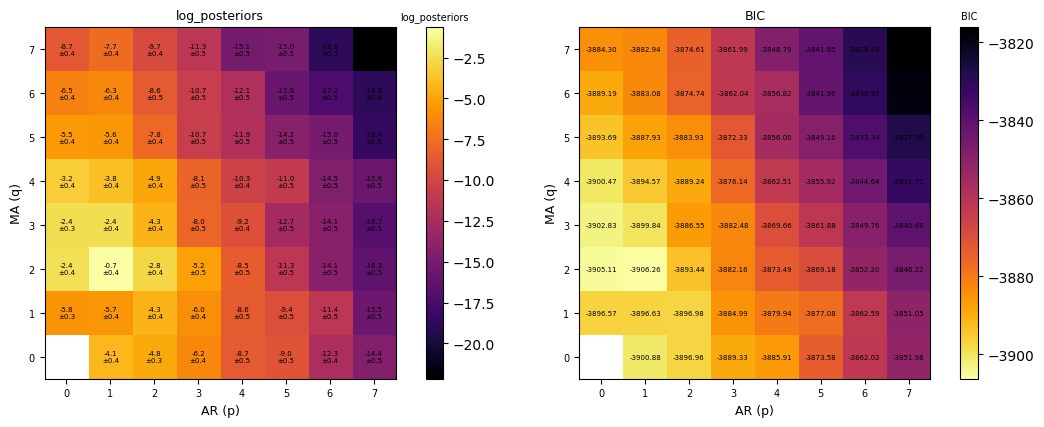

In [23]:
data_binned.compare(quantity2="BIC")
plt.show()

In [24]:
#Evidence and BIC agree.
print(f"Evidence argmax: {np.argmax(data_binned.log_posteriors)}; BIC argmin: {np.argmin(data_binned.BIC)}") 

Evidence argmax: 9; BIC argmin: 9


In [25]:
data_binned.cumulative_posterior_mass(5)

{'n': 5,
 'top_orders': [(1, 1, 2), (0, 1, 2), (1, 1, 3), (0, 1, 3), (2, 1, 2)],
 'individual_mass': array([0.5165459 , 0.0935692 , 0.08761619, 0.08737467, 0.0630275 ]),
 'cumulative_mass': 0.8481334491076942}

Running Nested Sampling for fitting ARIMA (1, 1, 2) model...


Dead points: 45200 dead points [07:08, 105.49 dead points/s]


Finished Nested Sampling with a total runtime of : 429.50 seconds
||NESTED SAMPLING SUMMARY RESULTS||
----------------------------------------------------
Nested sampling runtime: 429.50 seconds
----------------------------------------------------
Posterior mean for phi_1 : 0.9769998647869351
Posterior mean for theta_1 : -0.14224234365586702
Posterior mean for theta_2 : 0.13961524457639993
Posterior mean for sigma : 0.02391055623932338
Posterior mean for mu : 3.3844979330224964e-05
Posterior mean for init_y_1 : -0.0007905146671486298
---------------------------------------------------
Log Evidence: 1931.97 ± 0.19
-------x----------------x-------------x------------


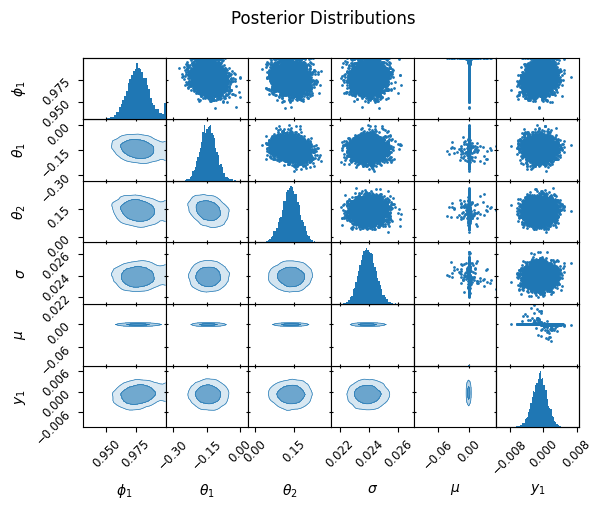

In [12]:
model = ARIMA_ns.ARIMA_Nested_Sampler(data=blazar_flux,meas_sigma=None,order=(1,1,2),num_live=1000,num_delete=50,mu_mean=0,mu_scale=5,seed=30)
model.summary()
plt.show()

Running Nested Sampling for fitting ARIMA (1, 1, 2) model...


Dead points: 43000 dead points [07:10, 99.78 dead points/s] 


Finished Nested Sampling with a total runtime of : 432.22 seconds
||NESTED SAMPLING SUMMARY RESULTS||
----------------------------------------------------
Nested sampling runtime: 432.22 seconds
----------------------------------------------------
Posterior mean for phi_1 : 0.9769628827577926
Posterior mean for theta_1 : -0.13889729425415656
Posterior mean for theta_2 : 0.14084061249512383
Posterior mean for sigma : 0.00593339433727684
Posterior mean for mu : 0.0001320406672780193
Posterior mean for init_y_1 : -0.0009810852483479525
---------------------------------------------------
Log Evidence: 1935.95 ± 0.18
-------x----------------x-------------x------------


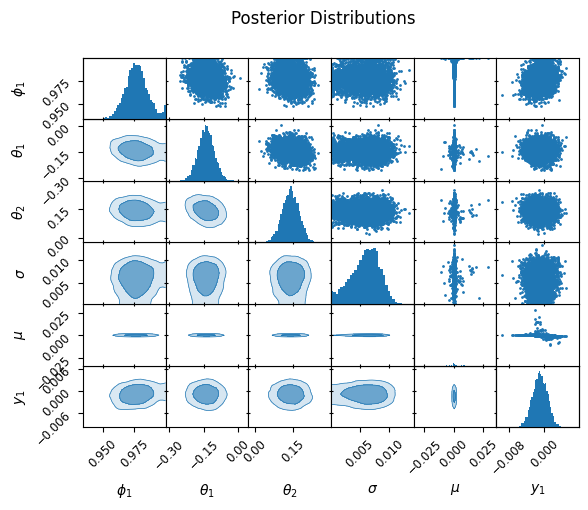

In [18]:
model_sigma_meas = ARIMA_ns.ARIMA_Nested_Sampler(data=blazar_flux,meas_sigma=blazar_error,order=(1,1,2),num_live=1000,num_delete=50,mu_mean=0,mu_scale=5,seed=30)
model_sigma_meas.summary()
plt.show()

In [24]:
model_sigma_meas.posterior_samples.to_csv("NS Chains/S4_0954+64_samples_meas_sigma.csv")

PosteriorResults: order=(1, 1, 2), prior_type='normal' (inferred from chain)


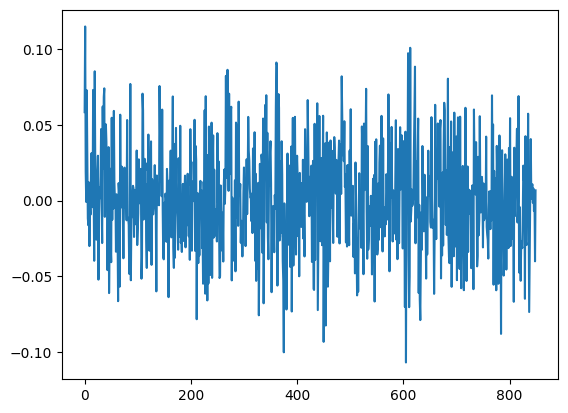

In [29]:
blazar_posteriors = ar.PosteriorResults("NS Chains/S4_0954+65_samples.csv",blazar_flux,d=1)
blazar_point_estimate = blazar_posteriors.point_estimate_forecast("mean",deterministic=False)
blazar_residual = blazar_point_estimate["residuals"]
plt.plot(blazar_residual)
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/arima_results.py:1010: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


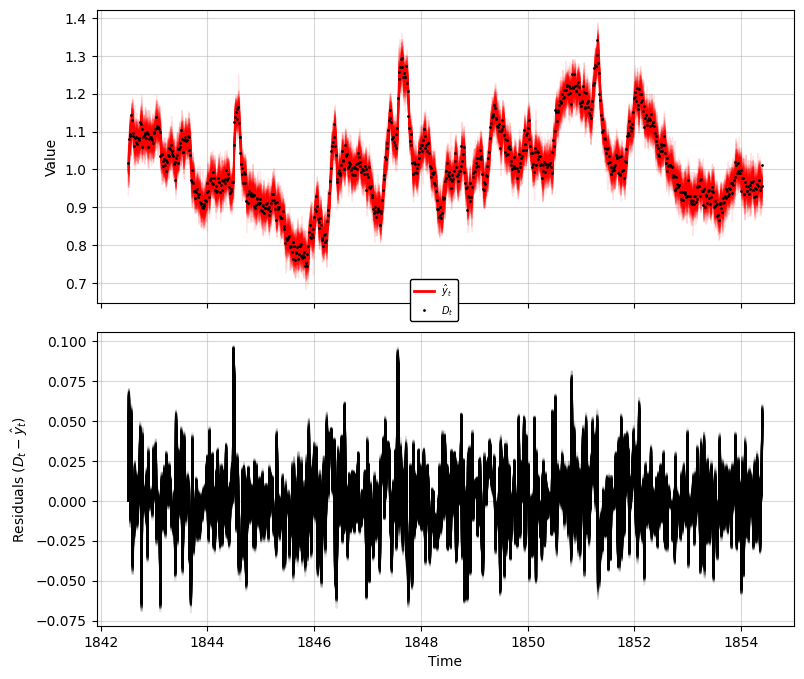

In [34]:
blazar_posteriors.insample_forecast(blazar_time,n_samples=1000,seed=33,deterministic=False)
plt.show()

In [33]:
sm.stats.acorr_ljungbox(blazar_residual, lags=np.arange(10,21,1), return_df=True,model_df=3)

,lb_stat,lb_pvalue
10,16.050760,0.024657
11,17.284995,0.027275
12,18.283922,0.032019
13,20.649764,0.023673
14,21.079403,0.032558
15,21.140979,0.048354
16,22.379663,0.049751
17,26.080471,0.025284
18,28.017537,0.021460
19,29.315109,0.021896
